In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Libraries
Pandas, NumPy, Matplotlib and Seaborn libraries are imported for data analysis and visualization.

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Load Dataset
The Titanic dataset is loaded using pandas and first few rows are displayed.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Dataset Info
Dataset information is checked to see columns, data types and missing values.

In [4]:
df.drop(['Cabin','Ticket','Name'], axis=1, inplace=True)

### Data Cleaning
Unnecessary columns like Cabin, Ticket and Name are removed.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


### Dataset Info
Dataset information is checked to see columns, data types and missing values.

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Missing values in Age column are filled using median.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


### Dataset Info
Dataset information is checked to see columns, data types and missing values.

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Missing values in Embarked column are filled using mode.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


### Dataset Info
Dataset information is checked to see columns, data types and missing values.

In [12]:
df['FamilySize'] = df['SibSp'] + df['Parch']

### Feature Engineering
New feature FamilySize is created using SibSp and Parch.

In [13]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,19,40,60,100],labels=['Child','Teen','Adult','Middle','Old'])

AgeGroup feature is created to divide passengers into age categories.

In [14]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,male,22.0,1,0,7.2500,S,1,Adult
1,2,1,1,female,38.0,1,0,71.2833,C,1,Adult
2,3,1,3,female,26.0,0,0,7.9250,S,0,Adult
3,4,1,1,female,35.0,1,0,53.1000,S,1,Adult
4,5,0,3,male,35.0,0,0,8.0500,S,0,Adult


Dataset is checked after cleaning and feature creation.

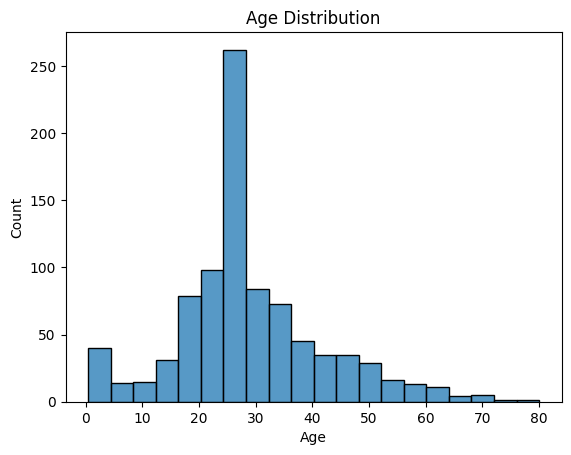

In [15]:
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

Most passengers are between age 20 to 40.
Very few passengers are children and old age people.
The dataset mostly contains adults.

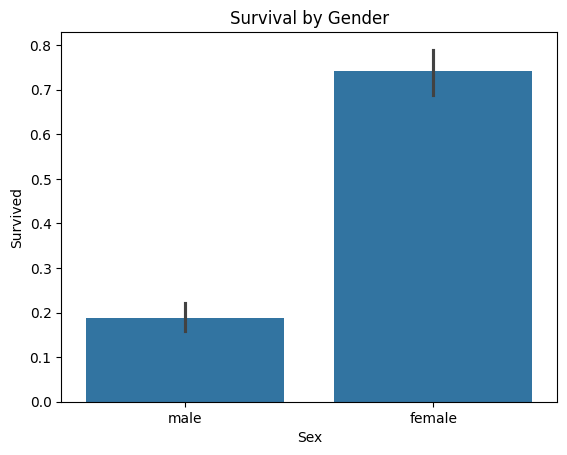

In [16]:
plt.figure()
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

Females have higher survival rate than males.
Most males did not survive.

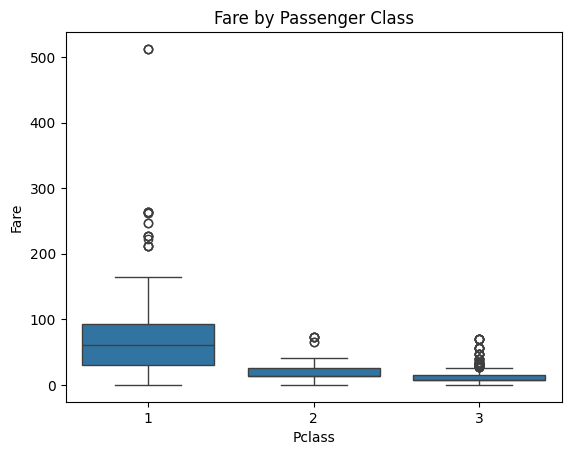

In [17]:
plt.figure()
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare by Passenger Class")
plt.show()

First class passengers paid the highest fare.
Third class passengers paid the lowest fare.
There are some outliers with very high fare.

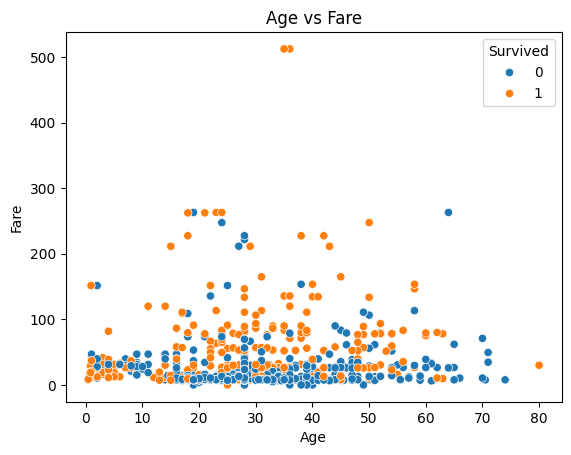

In [18]:
plt.figure()
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare")
plt.show()

Higher fare passengers have more survival chances.

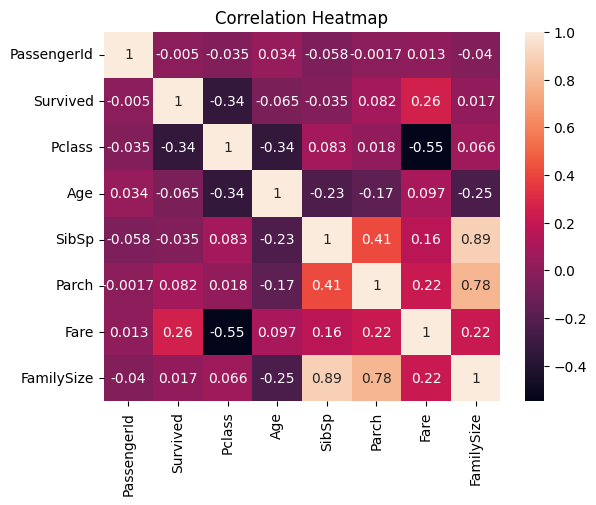

In [19]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Fare and Survival have positive correlation, meaning passengers who paid higher fare had more chances to survive.

Conclusion:
From the visualizations, survival was affected by gender, class, and fare.
Females and first-class passengers had higher survival chances.
Data visualization helps in understanding patterns in the dataset.